## 1. Datos y preparación

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score, adjusted_rand_score

sns.set_style("whitegrid")
SEED = 42
PALETA = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100"]

RUTA = Path("datos") if Path("datos").exists() else Path("../datos")

df = pd.read_parquet(RUTA / "base_tareas.parquet")
print(f"Establecimientos: {df.shape[0]}  |  Columnas: {df.shape[1]}")
df.head(3)

Establecimientos: 1526  |  Columnas: 14


,rbd,depe,zona,gse,cod_reg_rbd,convivencia,autoestima_motiv,vida_saludable,participacion,target_bin,prom_mate2m_rbd,ive_media,promedio_estandarizado,pct_acuerdo_promedio
0,40126,Municipal,Urbano,Bajo,4,75.0,74.0,73.0,79.0,0,233.0,0.922,0.051435,41.304348
1,6853,Municipal,Rural,Bajo,14,71.0,72.0,73.0,73.0,0,213.0,1.000,0.200372,46.078431
2,26372,Part. subvencionado,Urbano,Bajo,13,79.0,76.0,76.0,81.0,1,259.0,0.948,-0.239126,31.313131


### 1.2 Colinealidad entre los indicadores IDPS

Antes de elegir las variables de entrada revisamos cómo se relacionan los cuatro indicadores IDPS
entre sí.

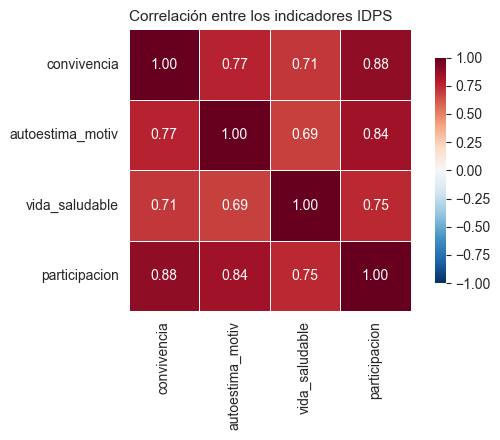

In [2]:
idps = ["convivencia", "autoestima_motiv", "vida_saludable", "participacion"]

fig, ax = plt.subplots(figsize=(6, 4.5))
sns.heatmap(df[idps].corr(), annot=True, fmt=".2f", cmap="RdBu_r", vmin=-1, vmax=1,
            center=0, square=True, linewidths=0.5, cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title("Correlación entre los indicadores IDPS", fontsize=11, loc="left")
plt.tight_layout(); plt.show()

Las correlaciones van de **0.69 a 0.88**: los cuatro indicadores están midiendo esencialmente la
misma dimensión latente, el *clima escolar*. Esto tiene dos consecuencias, una para cada tarea:

- **Para el clustering:** si se ingresan los cuatro por separado, esa única dimensión aporta 4 de
  las variables y domina el cálculo de distancias, aplastando a las demás. Los grupos resultantes
  reflejarían solo el nivel de IDPS.
- **Para la clasificación:** con correlaciones de esta magnitud, la regresión no puede repartir el
  crédito entre variables casi idénticas y los coeficientes se vuelven inestables e
  ininterpretables.

**Decisión:** se resumen los cuatro IDPS en un único índice (`idps_index`), promedio de las cuatro
variables estandarizadas. El costo es no poder afirmar cuál IDPS específico pesa más; con
correlaciones de 0.88 esa afirmación no era defendible de todos modos.

In [3]:
d = df.dropna(subset=idps + ["promedio_estandarizado", "ive_media"]).copy()
print(f"Excluidos por valores faltantes: {len(df) - len(d)} establecimientos "
      f"({(len(df) - len(d)) / len(df) * 100:.1f}%)")

# indice de clima escolar: promedio de los 4 IDPS estandarizados
d["idps_index"] = StandardScaler().fit_transform(d[idps]).mean(axis=1)

# nombres de establecimiento, solo para la revision cualitativa de casos
simce = pd.read_parquet(RUTA / "simce2m2024_rbd_preliminar.parquet")
d = d.merge(simce[["rbd", "nom_rbd", "nom_com_rbd"]], on="rbd", how="left")

print(f"Muestra analítica final: {len(d)} establecimientos")
d[["idps_index", "promedio_estandarizado", "ive_media"]].describe().round(3)

Excluidos por valores faltantes: 97 establecimientos (6.4%)
Muestra analítica final: 1429 establecimientos


,idps_index,promedio_estandarizado,ive_media
count,1429.000,1429.000,1429.000
mean,0.000,-0.004,0.889
std,0.912,0.233,0.061
min,-2.640,-0.995,0.593
25%,-0.625,-0.149,0.854
50%,-0.046,0.010,0.897
75%,0.586,0.144,0.934
max,3.609,0.796,1.000


Los 97 establecimientos excluidos (6.4%) son aquellos sin indicador de creencias de género, por tener menos del 90% de respuesta en el cuestionario de
estudiantes.

---
# 2. Clustering

## 2.1 Algoritmo, datos usados y ajuste de parámetros

### Variables de entrada

Se agrupan los establecimientos según **tres dimensiones de igual peso**:

| Variable | Dimensión que representa |
| :--- | :--- |
| `idps_index` | Clima escolar (proceso interno del establecimiento) |
| `promedio_estandarizado` | Creencias de género del estudiantado |
| `ive_media` | Vulnerabilidad socioeconómica (contexto) |

Estas tres son casi ortogonales entre sí, de modo que ninguna domina la distancia. Se excluyen
deliberadamente:

- `prom_mate2m_rbd` y `target_bin`: son el resultado. Si se usaran para formar los grupos, la
  asociación posterior entre perfil y desempeño sería circular y no probaría nada.
- Las variables categóricas (`depe`, `zona`, `gse`): Se usan
  después para **describir** los grupos, que es donde son realmente útiles.

### Estandarización

`StandardScaler` deja las tres variables en media 0 y desviación 1. Es imprescindible: `ive_media`
va de 0 a 1 mientras que `idps_index` se mueve en varias unidades, y sin escalar la primera casi no
influiría en la distancia euclidiana.

In [4]:
vars_cluster = ["idps_index", "promedio_estandarizado", "ive_media"]

X = StandardScaler().fit_transform(d[vars_cluster])
print("Matriz de entrada:", X.shape)

Matriz de entrada: (1429, 3)


### ¿Tiene sentido buscar grupos? (estadístico de Hopkins)

k-means **siempre** devuelve una partición, exista o no estructura real en los datos. El
estadístico de Hopkins se calcula *antes* de agrupar y compara las distancias entre puntos reales
con las de puntos generados al azar de forma uniforme en el mismo espacio.

- H ≈ 0.5 → los datos son indistinguibles de ruido uniforme.
- H → 1 → los datos se concentran, hay estructura no aleatoria.

In [5]:
rng = np.random.default_rng(SEED)

def hopkins(Xa, m=None):
    """Estadístico de Hopkins sobre una muestra de m puntos."""
    n, p = Xa.shape
    m = m or int(0.1 * n)
    vecinos = NearestNeighbors(n_neighbors=2).fit(Xa)

    # distancia de cada punto real a su vecino real mas cercano
    idx = rng.choice(n, m, replace=False)
    dist_reales = vecinos.kneighbors(Xa[idx], n_neighbors=2)[0][:, 1]

    # distancia de puntos artificiales uniformes al punto real mas cercano
    artificiales = rng.uniform(Xa.min(0), Xa.max(0), (m, p))
    dist_artificiales = vecinos.kneighbors(artificiales, n_neighbors=1)[0][:, 0]

    return dist_artificiales.sum() / (dist_artificiales.sum() + dist_reales.sum())

print(f"Hopkins (promedio de 10 repeticiones): {np.mean([hopkins(X) for _ in range(10)]):.3f}")

Hopkins (promedio de 10 repeticiones): 0.819


El valor obtenido (≈0.82) supera holgadamente el umbral de referencia de 0.75, así que los datos
**no** son ruido uniforme. Pero conviene leerlo con cuidado: Hopkins detecta *desviación de la
uniformidad*, y una nube con forma gaussiana también la produce sin contener grupo alguno. Es
condición necesaria, no suficiente.

### Selección del número de grupos

Se evalúan dos criterios sobre un rango de k:

- **Inercia** (método del codo): suma de distancias al cuadrado de cada punto a su centroide. Baja
  siempre al aumentar k; se busca el "codo" donde deja de bajar rápido.
- **Silhouette**: para cada establecimiento compara su distancia a los de su propio grupo con la
  distancia al grupo vecino más cercano. Va de −1 a 1; cerca de 0 significa que el caso está en la
  frontera entre dos grupos.

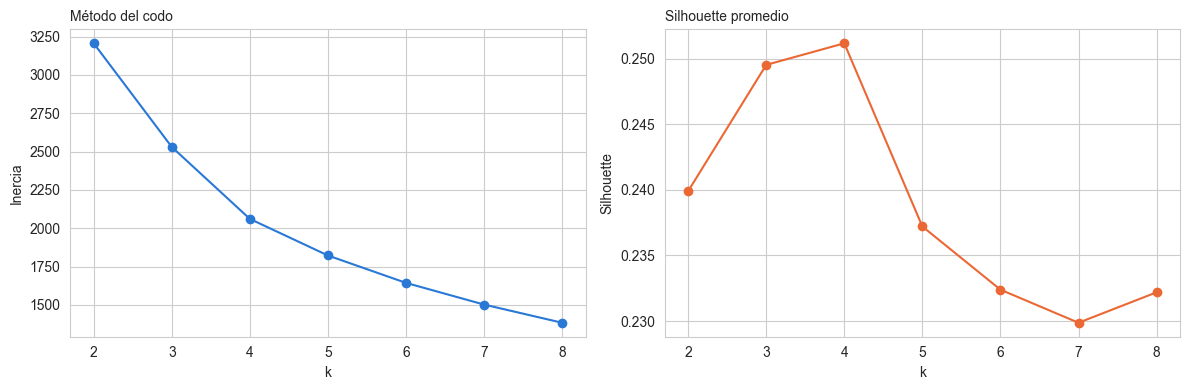

,inercia,silhouette
k,,
2,3206.171,0.240
3,2530.142,0.250
4,2060.985,0.251
5,1822.428,0.237
6,1643.718,0.232
7,1502.288,0.230
8,1383.701,0.232


In [6]:
evaluacion = []
for k in range(2, 9):
    km_k = KMeans(n_clusters=k, random_state=SEED, n_init=10).fit(X)
    evaluacion.append({"k": k,
                       "inercia": km_k.inertia_,
                       "silhouette": silhouette_score(X, km_k.labels_)})

evaluacion = pd.DataFrame(evaluacion).set_index("k")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(evaluacion.index, evaluacion["inercia"], marker="o", color=PALETA[0])
axes[0].set_xlabel("k"); axes[0].set_ylabel("Inercia")
axes[0].set_title("Método del codo", fontsize=10, loc="left")

axes[1].plot(evaluacion.index, evaluacion["silhouette"], marker="o", color=PALETA[1])
axes[1].set_xlabel("k"); axes[1].set_ylabel("Silhouette")
axes[1].set_title("Silhouette promedio", fontsize=10, loc="left")

plt.tight_layout(); plt.show()
evaluacion.round(3)

**Lectura del resultado.** La curva de silhouette es **plana**: oscila entre 0.23 y 0.25 sin que
ningún k destaque. Si existieran grupos realmente separados se observaría un peak nítido. La
inercia tampoco muestra un codo marcado.

Sumado al nivel absoluto (≈0.25, en el límite inferior de lo que se considera estructura débil), la
conclusión es clara y hay que declararla explícitamente:

> **Los establecimientos no forman grupos naturalmente separados: forman un continuo.** El
> clustering aquí no *descubre* tipos preexistentes, sino que **segmenta un gradiente** en tramos
> descriptivos y comparables.

Esto no invalida la tarea, pero sí cambia el criterio de decisión: **como la métrica es indiferente
entre k = 2, 3 y 4, el número de grupos se elige por interpretabilidad y utilidad**, no maximizando
silhouette.

### Comparación con algoritmos alternativos

Antes de fijar k-means se contrastan tres algoritmos con supuestos distintos:

- **k-means**: grupos esféricos de tamaño similar; minimiza la distancia al centroide.
- **Aglomerativo (Ward)**: jerárquico, fusiona sucesivamente los pares que menos aumentan la
  varianza interna.
- **Gaussian Mixture (GMM)**: grupos elipsoidales con orientación propia; asignación probabilística
  en lugar de partición dura.

El **Adjusted Rand Index (ARI)** mide el acuerdo entre dos particiones: 0 = coincidencia esperable
por azar, 1 = idénticas.

In [7]:
K = 4

etiquetas = {
    "k-means":      KMeans(n_clusters=K, random_state=SEED, n_init=10).fit_predict(X),
    "Ward":         AgglomerativeClustering(n_clusters=K, linkage="ward").fit_predict(X),
    "GMM":          GaussianMixture(n_components=K, covariance_type="full",
                                    random_state=SEED, n_init=5).fit_predict(X),
}

comparacion = pd.DataFrame({
    "silhouette": {n: silhouette_score(X, l) for n, l in etiquetas.items()},
    "ARI vs k-means": {n: adjusted_rand_score(etiquetas["k-means"], l) for n, l in etiquetas.items()},
})
comparacion.round(3)

,silhouette,ARI vs k-means
k-means,0.251,1.000
Ward,0.186,0.279
GMM,0.235,0.503


**Se selecciona k-means**: obtiene el mejor silhouette, es el más simple de explicar y sus
centroides son directamente interpretables como el perfil promedio del grupo. Con datos sin
estructura discreta, el método más simple es también el más defendible.

In [8]:
kmeans = KMeans(n_clusters=K, random_state=SEED, n_init=10).fit(X)
d["perfil"] = kmeans.labels_

print(f"Silhouette final: {silhouette_score(X, d['perfil']):.3f}")
d["perfil"].value_counts().sort_index().rename("n establecimientos")

Silhouette final: 0.251


perfil
0    450
1    309
2    266
3    404
Name: n establecimientos, dtype: int64

## 2.2 Visualización, revisión de casos e interpretación de los grupos

### Proyección en componentes principales

Las tres variables no se pueden graficar en un plano, así que se proyectan con PCA sobre los dos
componentes que más varianza capturan.

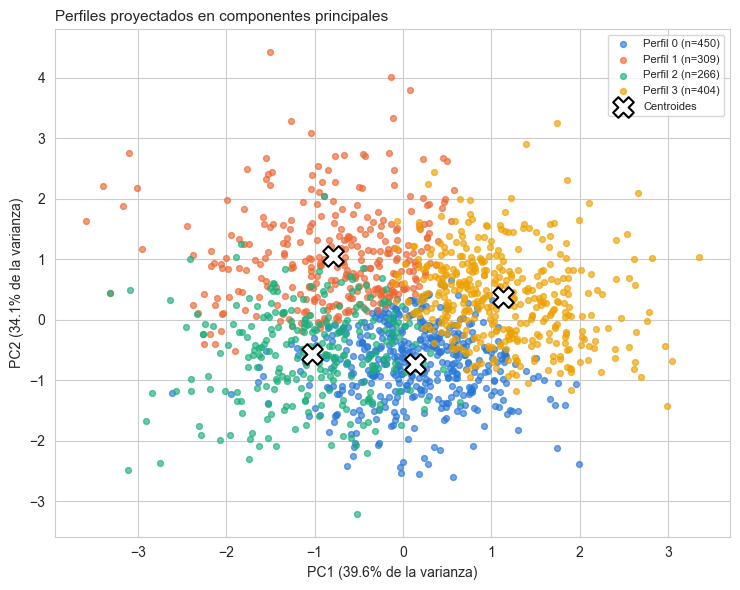

In [9]:
pca = PCA(n_components=2, random_state=SEED)
coords = pca.fit_transform(X)

fig, ax = plt.subplots(figsize=(7.5, 6))
for c in range(K):
    m = d["perfil"] == c
    ax.scatter(coords[m, 0], coords[m, 1], s=18, alpha=0.65,
               color=PALETA[c], label=f"Perfil {c} (n={m.sum()})")

centros = pca.transform(kmeans.cluster_centers_)
ax.scatter(centros[:, 0], centros[:, 1], marker="X", s=220,
           c="white", edgecolors="black", linewidths=1.5, zorder=5, label="Centroides")

ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% de la varianza)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% de la varianza)")
ax.set_title("Perfiles proyectados en componentes principales", fontsize=11, loc="left")
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

Los dos componentes recogen ~74% de la varianza y se reparten de forma pareja (39.6% y 34.1%), lo
que confirma que el espacio quedó **equilibrado**: ninguna dimensión domina. El gráfico muestra
grupos contiguos sin espacios vacíos entre ellos — la representación visual de que estamos
segmentando un continuo.

### Perfil promedio de cada grupo

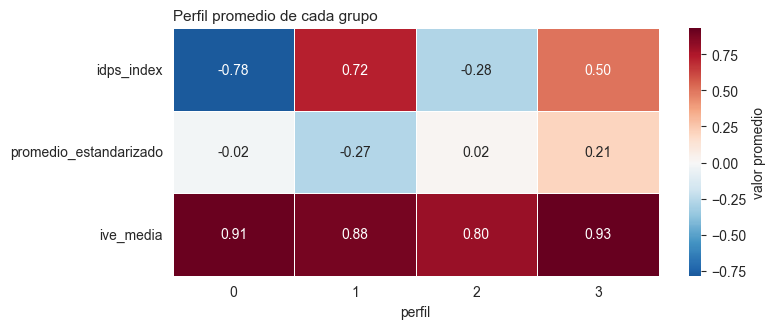

,idps_index,promedio_estandarizado,ive_media,n
perfil,,,,
0,-0.783,-0.021,0.911,450
1,0.719,-0.270,0.884,309
2,-0.275,0.016,0.798,266
3,0.503,0.206,0.929,404


In [10]:
perfiles = (d.groupby("perfil")[vars_cluster]
              .mean()
              .assign(n=d["perfil"].value_counts().sort_index()))

fig, ax = plt.subplots(figsize=(8, 3.4))
sns.heatmap(perfiles[vars_cluster].T, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            linewidths=0.5, cbar_kws={"label": "valor promedio"}, ax=ax)
ax.set_title("Perfil promedio de cada grupo", fontsize=11, loc="left")
ax.set_xlabel("perfil"); ax.set_ylabel("")
plt.tight_layout(); plt.show()

perfiles.round(3)

`idps_index` y `promedio_estandarizado` están en desviaciones estándar (0 = promedio de la
muestra). `ive_media` es una proporción cuyo promedio general es 0.89, de modo que 0.93 indica
mayor vulnerabilidad que la típica y 0.80 bastante menos.

### Composición de cada grupo según variables categóricas

Estas variables no participaron en la formación de los grupos; sirven para caracterizarlos.

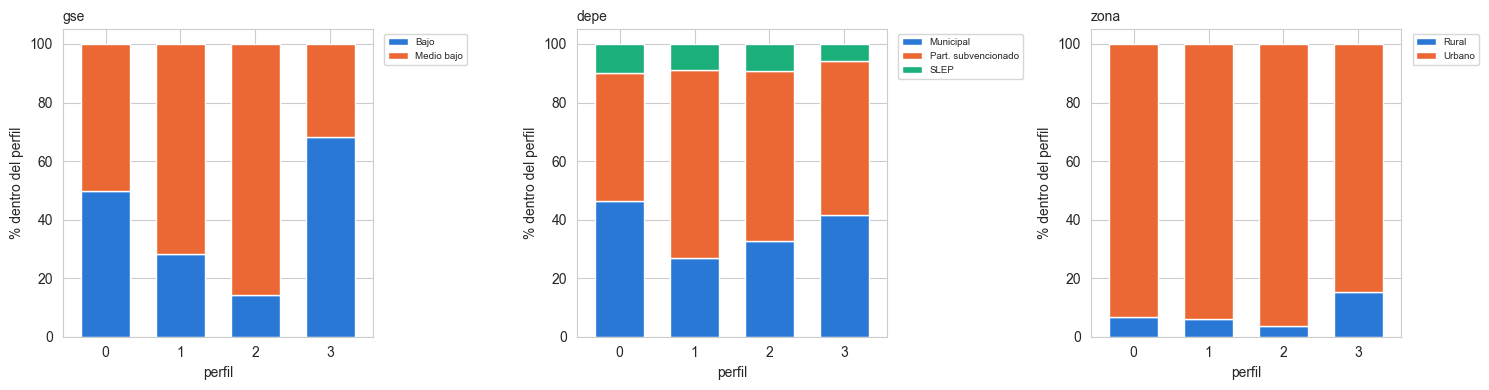

gse,Bajo,Medio bajo
perfil,,
0,49.8,50.2
1,28.2,71.8
2,14.3,85.7
3,68.3,31.7


In [11]:
categoricas = ["gse", "depe", "zona"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, var in zip(axes, categoricas):
    tabla = pd.crosstab(d["perfil"], d[var], normalize="index") * 100
    tabla.plot(kind="bar", stacked=True, ax=ax, width=0.65,
               color=PALETA[:tabla.shape[1]])
    ax.set_title(var, fontsize=10, loc="left")
    ax.set_xlabel("perfil"); ax.set_ylabel("% dentro del perfil")
    ax.tick_params(axis="x", rotation=0)
    ax.legend(fontsize=7, bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout(); plt.show()

pd.crosstab(d["perfil"], d["gse"], normalize="index").round(3) * 100

### Revisión de casos: establecimientos representativos

Para cada grupo se muestran los tres establecimientos **más cercanos a su centroide**, es decir los
casos más típicos del perfil.

In [12]:
distancias = kmeans.transform(X)

representativos = []
for c in range(K):
    idx = np.where(d["perfil"].values == c)[0]
    mas_cercanos = idx[np.argsort(distancias[idx, c])[:3]]
    representativos.append(d.iloc[mas_cercanos])

(pd.concat(representativos)[["perfil", "rbd", "nom_rbd", "nom_com_rbd", "depe"]
                            + vars_cluster + ["prom_mate2m_rbd"]]
   .round(2).set_index("perfil"))

,rbd,nom_rbd,nom_com_rbd,depe,idps_index,promedio_estandarizado,ive_media,prom_mate2m_rbd
perfil,,,,,,,,
0,2111,LICEO MUNICIPAL JOSE VICTORINO LASTARR,RANCAGUA,Municipal,-0.83,0.01,0.91,225.0
0,2206,ESCUELA SIXTO MENDEZ PARADA,GRANEROS,Municipal,-0.75,0.02,0.92,222.0
0,17885,CENTRO EDUCACIONAL BICENTENARIO ALTOS,TOMÉ,Municipal,-0.62,-0.04,0.91,261.0
1,14616,COLEGIO LOS PRINCIPES,VIÑA DEL MAR,Part. subvencionado,0.65,-0.27,0.88,245.0
1,31037,LICEO INSTITUTO CUMBRE DE CONDORES,RENCA,Municipal,0.67,-0.31,0.88,293.0
1,2406,LICEO MUNICIPAL LUIS GREGORIO VALENZUE,COINCO,Municipal,0.55,-0.30,0.88,235.0
2,8625,CENTRO EDUC. CASA TALLERES SAN VICENTE,SANTIAGO,Part. subvencionado,-0.20,0.04,0.79,239.0
2,1450,COLEGIO SANTA ISABEL,NOGALES,Part. subvencionado,-0.35,0.07,0.79,250.0
2,25950,COLEGIO SEMPER ALTIUS,LA FLORIDA,Part. subvencionado,-0.15,0.03,0.78,219.0


### Relación entre perfil y logro académico

`prom_mate2m_rbd` y `target_bin` **no** participaron en la construcción de los grupos. Si aun así
difieren entre perfiles, la diferencia es un hallazgo genuino y no un artefacto.

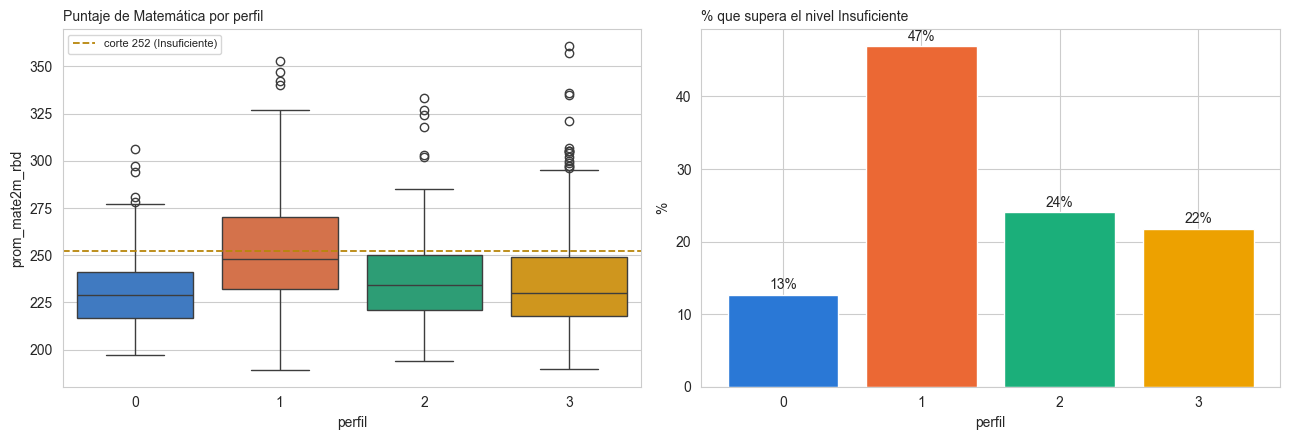

,n,puntaje_promedio,pct_supera
perfil,,,
0,450,230.6,12.7
1,309,251.8,46.9
2,266,237.3,24.1
3,404,236.2,21.8


In [13]:
logro = (d.groupby("perfil")
           .agg(n=("rbd", "size"),
                puntaje_promedio=("prom_mate2m_rbd", "mean"),
                pct_supera=("target_bin", "mean"))
           .assign(pct_supera=lambda t: t["pct_supera"] * 100)
           .round(1))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.boxplot(data=d, x="perfil", y="prom_mate2m_rbd", hue="perfil", legend=False,
            palette=PALETA, ax=axes[0])
axes[0].axhline(252, color="#b8860b", ls="--", lw=1.3, label="corte 252 (Insuficiente)")
axes[0].set_title("Puntaje de Matemática por perfil", fontsize=10, loc="left")
axes[0].legend(fontsize=8)

axes[1].bar(logro.index.astype(str), logro["pct_supera"], color=PALETA)
for i, v in enumerate(logro["pct_supera"]):
    axes[1].text(i, v + 0.7, f"{v:.0f}%", ha="center", fontsize=10)
axes[1].set_title("% que supera el nivel Insuficiente", fontsize=10, loc="left")
axes[1].set_xlabel("perfil"); axes[1].set_ylabel("%")

plt.tight_layout(); plt.show()
logro

### ¿Las diferencias entre perfiles son estadísticamente significativas?

El gráfico anterior muestra diferencias, pero conviene comprobar que no sean atribuibles al azar.
Se procede en dos pasos:

1. **ANOVA**: contrasta la hipótesis de que los cuatro perfiles tienen el mismo puntaje promedio.
2. **Comparaciones por pares**: si el ANOVA rechaza, se identifica *qué* pares difieren. Con cuatro
   grupos hay **6 comparaciones posibles**, y realizar 6 pruebas independientes al 5% eleva la
   probabilidad de encontrar al menos un falso positivo por encima del 26%. Se aplica la
   **corrección de Bonferroni** (multiplicar cada p-valor por el número de pruebas) para mantener el
   error global en 5%.

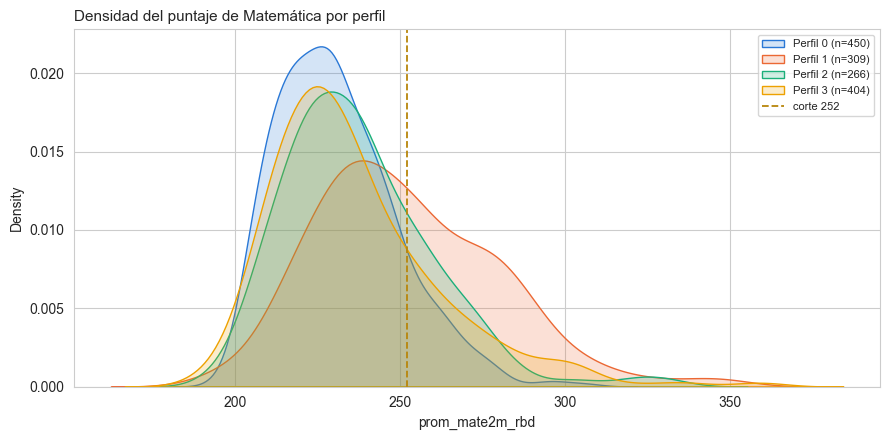

ANOVA: F = 50.33, p = 6.44e-31


,dif_puntaje,p_bonferroni,significativa
comparación,,,
perfil 0 vs 1,-21.2011,0.0000,sí
perfil 0 vs 2,-6.6914,0.0003,sí
perfil 0 vs 3,-5.6621,0.0017,sí
perfil 1 vs 2,14.5098,0.0000,sí
perfil 1 vs 3,15.5391,0.0000,sí
perfil 2 vs 3,1.0293,1.0000,NO


In [14]:
from scipy.stats import f_oneway, ttest_ind, chi2_contingency
from itertools import combinations

grupos = [d.loc[d["perfil"] == c, "prom_mate2m_rbd"] for c in range(K)]

# distribucion del puntaje por perfil
fig, ax = plt.subplots(figsize=(9, 4.5))
for c in range(K):
    sns.kdeplot(grupos[c], ax=ax, color=PALETA[c], fill=True, alpha=0.2,
                label=f"Perfil {c} (n={len(grupos[c])})")
ax.axvline(252, color="#b8860b", ls="--", lw=1.3, label="corte 252")
ax.set_xlabel("prom_mate2m_rbd")
ax.set_title("Densidad del puntaje de Matemática por perfil", fontsize=11, loc="left")
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

F, p_anova = f_oneway(*grupos)
print(f"ANOVA: F = {F:.2f}, p = {p_anova:.2e}")

n_pruebas = len(list(combinations(range(K), 2)))
pares = []
for a, b in combinations(range(K), 2):
    t, p = ttest_ind(grupos[a], grupos[b], equal_var=False)   # Welch, no asume varianzas iguales
    p_corregido = min(p * n_pruebas, 1.0)
    pares.append({"comparación": f"perfil {a} vs {b}",
                  "dif_puntaje": grupos[a].mean() - grupos[b].mean(),
                  "p_bonferroni": p_corregido,
                  "significativa": "sí" if p_corregido < 0.05 else "NO"})

pd.DataFrame(pares).set_index("comparación").round(4)

In [15]:
# la asociacion entre perfil y el target binario tambien se contrasta
chi2, p_chi2, gl, _ = chi2_contingency(pd.crosstab(d["perfil"], d["target_bin"]))
print(f"Chi-cuadrado (perfil vs target_bin): chi2 = {chi2:.2f}, gl = {gl}, p = {p_chi2:.2e}")

Chi-cuadrado (perfil vs target_bin): chi2 = 118.77, gl = 3, p = 1.42e-25


**El ANOVA rechaza contundentemente** la igualdad de medias (F = 50.3, p ≈ 6×10⁻³¹), y el
chi-cuadrado confirma la asociación entre perfil y target (p ≈ 1×10⁻²⁵). Los perfiles capturan
diferencias reales de desempeño.

**Las comparaciones por pares aportan el detalle decisivo: cinco de las seis son significativas, y
la única que no lo es es perfil 2 vs perfil 3** (diferencia de apenas 1.03 puntos, p corregido =
1.000).

### Interpretación de los perfiles

Ordenados por tasa de logro:

| Perfil | Nombre propuesto | Clima | Género | IVE | Supera | n |
| :---: | :--- | ---: | ---: | ---: | ---: | ---: |
| **1** | Clima favorable, baja vulnerabilidad | +0.72 | −0.27 | 0.88 | **47%** | 309 |
| **2** | Clima débil, baja vulnerabilidad | −0.28 | +0.02 | 0.80 | 24% | 266 |
| **3** | Clima favorable, alta vulnerabilidad | +0.50 | +0.21 | 0.93 | 22% | 404 |
| **0** | Clima débil, alta vulnerabilidad | −0.78 | −0.02 | 0.91 | 13% | 450 |

**Hallazgo 1 — la tasa de logro va de 13% a 47%.** Una diferencia de casi cuatro veces entre
perfiles construidos sin usar el resultado. Los perfiles capturan algo real.

**Hallazgo 2 — un buen clima escolar no basta por sí solo.** Los perfiles 3 y 2 rinden igual (22% y
24%; **la única comparación por pares no significativa**, p corregido = 1.000) pese a tener climas
escolares opuestos: +0.50 el primero, −0.28 el segundo. Lo que los separa es la vulnerabilidad
(0.93 frente a 0.80).

**Hallazgo 3 — la vulnerabilidad parece fijar el techo y el clima mueve dentro de él.** Los dos
perfiles con mejor resultado son los de menor IVE (0.88 y 0.80) y los dos peores los de mayor IVE
(0.93 y 0.91); dentro de cada par, el de mejor clima rinde más. La comparación entre los perfiles 1
y 3 es la más elocuente: ambos con clima favorable, pero **47% contra 22%**.

**Precaución.** En estos perfiles las variables vienen entremezcladas: el perfil 3 es a la vez más
vulnerable *y* más estereotipado, de modo que esta tabla no permite atribuir el efecto a una u otra.
Separarlas es precisamente la tarea de la sección siguiente.

---
# 3. Clasificadores

## 3.1 Algoritmos, datos usados y ajuste de hiperparámetros

### Variable objetivo y desbalance

`target_bin` = 1 si el establecimiento supera los 252 puntos ("Elemental o adecuado"), 0 si queda
en "Insuficiente".

In [16]:
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.pipeline import make_pipeline
from sklearn.inspection import permutation_importance
from sklearn.metrics import (roc_auc_score, roc_curve, precision_recall_curve,
                             confusion_matrix, classification_report, accuracy_score,
                             precision_score, recall_score, f1_score)

print(d["target_bin"].value_counts().rename({0: "Insuficiente", 1: "Elemental o adecuado"}))
print(f"\nTasa de la clase positiva: {d['target_bin'].mean() * 100:.1f}%")

target_bin
Insuficiente            1075
Elemental o adecuado     354
Name: count, dtype: int64

Tasa de la clase positiva: 24.8%


Solo el 24.8% de los establecimientos alcanza el nivel. **Este desbalance obliga a descartar el
accuracy como métrica**: un modelo que prediga "Insuficiente" para todos acierta el 75% de las
veces y es completamente inútil.

La métrica principal será el **AUC-ROC**, que mide si el modelo asigna mayor probabilidad a un
establecimiento que sí supera el nivel que a uno que no. 0.5 = azar, 1.0 = perfecto. Además, todos
los modelos usan `class_weight="balanced"`, que pondera más a la clase minoritaria para que el
modelo no se rinda y prediga siempre la mayoritaria.

### Variables predictoras y exclusiones

Se incluyen `idps_index`, `promedio_estandarizado`, `ive_media` y `depe`. Las exclusiones son tan
importantes como las inclusiones:

| Excluida | Motivo |
| :--- | :--- |
| `prom_mate2m_rbd` | **Fuga de datos**: el target se derivó de ella. Produciría un AUC ≈ 1.0 falso |
| Los 4 IDPS por separado | Colinealidad de 0.69–0.88; se reemplazan por `idps_index` |
| `gse` | Mide lo mismo que `ive_media` (IVE promedio 0.92 en GSE Bajo vs 0.86 en Medio bajo). Incluir ambas las hace competir y anula el coeficiente de una. Se conserva `ive_media` por ser un gradiente continuo y más fino |
| `zona` | Su importancia por permutación resultó ≈ 0 en pruebas preliminares |
| `cod_reg_rbd` | Es un código, no una cantidad: la región 13 no es "trece veces" la región 1 |

In [17]:
continuas = ["idps_index", "promedio_estandarizado", "ive_media"]

Xc = pd.get_dummies(d[continuas + ["depe"]], columns=["depe"], drop_first=True).astype(float)
y = d["target_bin"]

X_tr, X_te, y_tr, y_te = train_test_split(Xc, y, test_size=0.25, stratify=y, random_state=SEED)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

print(f"Entrenamiento: {X_tr.shape[0]}  |  Prueba: {X_te.shape[0]}")
print(f"Predictoras: {list(Xc.columns)}")
print("\nCategoría de referencia de 'depe': Municipal (la que no aparece como columna)")

Entrenamiento: 1071  |  Prueba: 358
Predictoras: ['idps_index', 'promedio_estandarizado', 'ive_media', 'depe_Part. subvencionado', 'depe_SLEP']

Categoría de referencia de 'depe': Municipal (la que no aparece como columna)


`stratify=y` mantiene la misma proporción de clases en ambos conjuntos, indispensable con datos
desbalanceados.

### Los tres modelos

1. **Baseline (`DummyClassifier`)** — predice al azar respetando la proporción de clases. No es un
   competidor real: fija el piso contra el cual medir si los otros modelos aportan algo.
2. **Regresión logística** — modelo lineal. Su ventaja es que cada coeficiente se interpreta
   directamente como el efecto de una variable manteniendo las demás constantes, que es justo lo que
   pide la pregunta del proyecto.
3. **Random Forest** — conjunto de árboles. Captura relaciones no lineales e interacciones que la
   logística no puede. Sirve como contraste: si supera claramente a la logística, existen efectos
   no lineales relevantes.

### Ajuste de hiperparámetros

Se usa `GridSearchCV` con validación cruzada estratificada de 5 pliegues sobre el conjunto de
entrenamiento, optimizando AUC. El conjunto de prueba **no** interviene en la búsqueda.

- Logística: `C` (inverso de la fuerza de regularización). Valores bajos encogen los coeficientes
  hacia cero.
- Random Forest: `max_depth` (profundidad máxima) y `min_samples_leaf` (mínimo de casos por hoja).
  Ambos controlan el sobreajuste.

In [18]:
# el escalado va DENTRO del pipeline para que en cada pliegue se ajuste
# solo con los datos de entrenamiento de ese pliegue
pipe_logistica = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=1000, class_weight="balanced", random_state=SEED)
)

grid_logistica = GridSearchCV(
    pipe_logistica,
    {"logisticregression__C": [0.01, 0.1, 1, 10]},
    scoring="roc_auc", cv=cv, n_jobs=-1
).fit(X_tr, y_tr)

grid_rf = GridSearchCV(
    RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=SEED),
    {"max_depth": [None, 5, 10], "min_samples_leaf": [1, 5, 15]},
    scoring="roc_auc", cv=cv, n_jobs=-1
).fit(X_tr, y_tr)

print(f"Logística  -> mejor C: {grid_logistica.best_params_}  AUC CV: {grid_logistica.best_score_:.4f}")
print(f"Random Forest -> {grid_rf.best_params_}  AUC CV: {grid_rf.best_score_:.4f}")

pd.DataFrame({"C": grid_logistica.cv_results_["param_logisticregression__C"],
              "AUC_CV": grid_logistica.cv_results_["mean_test_score"]}).round(4)

Logística  -> mejor C: {'logisticregression__C': 0.01}  AUC CV: 0.7505
Random Forest -> {'max_depth': 5, 'min_samples_leaf': 15}  AUC CV: 0.7525


,C,AUC_CV
0,0.01,0.7505
1,0.10,0.7497
2,1.00,0.7496
3,10.00,0.7496


El baseline queda en ~0.57 (cerca del 0.5 esperable por azar) mientras ambos modelos reales rondan
0.80. La mejora es real y no un artefacto del desbalance.

**Random Forest 0.800 vs logística 0.798: diferencia despreciable.** Esto tiene una lectura
sustantiva importante. Si existieran interacciones o no linealidades relevantes —por ejemplo, que el
clima escolar rindiera distinto según el nivel de vulnerabilidad, como insinuaba la sección de
clustering— el Random Forest las habría capturado y habría sacado una ventaja clara. No la sacó,
de modo que **no hay evidencia que respalde esa hipótesis de interacción**.

Se adopta la **regresión logística como modelo principal**: capacidad predictiva equivalente y
coeficientes interpretables. La comparación se retoma con validación cruzada más adelante, que es
donde se decide formalmente.